In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\Kirti\Desktop\Global Supply Chain Performance\data\clean_supply_chain.csv",low_memory=False)

In [3]:
df.head(3)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Product Price,Product Status,shipping date (DateOrders),Shipping Mode,Order Year,Order Month,Day Name,Delivery Days,Delayed,Profit Margin
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,327.75,0,2018-03-02,Standard Class,2018,1,Wednesday,30.0,0,27.841342
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,327.75,0,2018-01-18,Standard Class,2018,1,Saturday,5.0,1,-75.999999
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,327.75,0,2018-01-17,Standard Class,2018,1,Saturday,4.0,0,-75.600305


In [4]:
df.shape

(180499, 57)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180499 entries, 0 to 180498
Data columns (total 57 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180499 non-null  object 
 1   Days for shipping (real)       180499 non-null  int64  
 2   Days for shipment (scheduled)  180499 non-null  int64  
 3   Benefit per order              180499 non-null  float64
 4   Sales per customer             180499 non-null  float64
 5   Delivery Status                180499 non-null  object 
 6   Late_delivery_risk             180499 non-null  int64  
 7   Category Id                    180499 non-null  int64  
 8   Category Name                  180499 non-null  object 
 9   Customer City                  180499 non-null  object 
 10  Customer Country               180499 non-null  object 
 11  Customer Email                 180499 non-null  object 
 12  Customer Fname                

In [6]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Product Card Id', 'Product Category Id', 'Product Image',
       'Product Na

In [7]:
df['Delivery Status'].value_counts()

Delivery Status
Late delivery        98970
Advance shipping     41582
Shipping on time     32193
Shipping canceled     7754
Name: count, dtype: int64

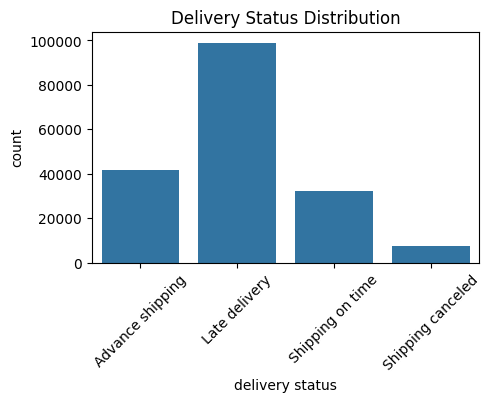

In [8]:
plt.figure(figsize=(5,3))
sns.countplot(x='Delivery Status',data=df)
plt.title("Delivery Status Distribution")
plt.xlabel("delivery status")
plt.xticks(rotation=45)
plt.show()

Late deliveries represent a significant portion of total orders, indicating operational inefficiencies in logistics and shipment management.

Top Countries with maximum delays

In [9]:
top_delays=(df.groupby('Order Country')['Delayed'].sum().sort_values(ascending=False).head(5))
top_delays

Order Country
Estados Unidos    13670
Francia            7341
Mxico             7246
Alemania           5383
Australia          4612
Name: Delayed, dtype: int64

Shipping Mode Performance

In [10]:
shipping_days=(df.groupby('Shipping Mode')['Delivery Days'].mean().sort_values(ascending=False))
shipping_days

Shipping Mode
Standard Class    8.429203
Second Class      5.406660
First Class      -2.026883
Same Day         -4.750716
Name: Delivery Days, dtype: float64

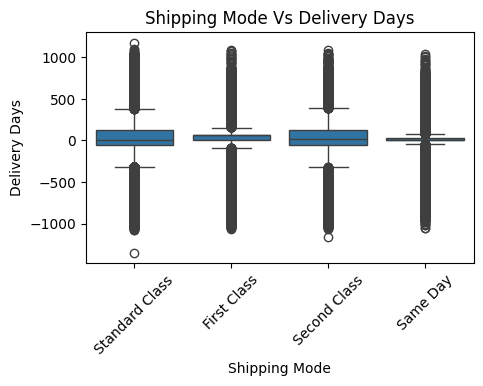

In [11]:
plt.figure(figsize=(5,3))
sns.boxplot(x='Shipping Mode',y='Delivery Days',data=df)
plt.title("Shipping Mode Vs Delivery Days")
plt.xticks(rotation=45)
plt.show()

Standard Class shipping shows higher average delivery times compared to premium shipping methods, suggesting a trade-off between cost and delivery speed.

Sales Performance by category

In [12]:
category_sales=(df.groupby('Category Name')['Sales'].sum().sort_values(ascending=False))
category_sales

Category Name
Fishing                 6.921654e+06
Cleats                  4.431943e+06
Camping & Hiking        4.118426e+06
Cardio Equipment        3.694843e+06
Women's Apparel         3.147800e+06
Water Sports            3.113845e+06
Men's Footwear          2.891758e+06
Indoor/Outdoor Games    2.888994e+06
Shop By Sport           1.309522e+06
Computers               6.630000e+05
Electronics             3.710346e+05
Cameras                 2.676077e+05
Garden                  2.577687e+05
Children's Clothing     2.328292e+05
Crafts                  2.233563e+05
Girls' Apparel          1.517062e+05
Women's Clothing        1.402830e+05
Accessories             1.336715e+05
Sporting Goods          1.170068e+05
Golf Gloves             1.166954e+05
Music                   1.131221e+05
Consumer Electronics    1.089913e+05
Golf Shoes              1.079980e+05
Health and Beauty       1.060805e+05
Kids' Golf Clubs        9.879758e+04
Baseball & Softball     9.405715e+04
Boxing & MMA            

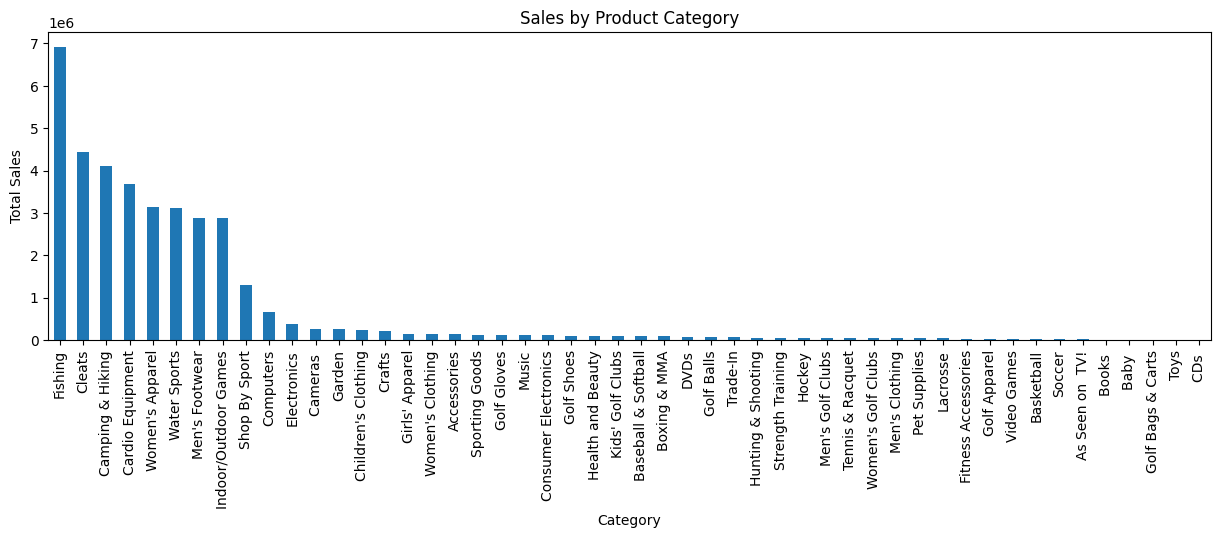

In [13]:
plt.figure(figsize=(15,4))
category_sales.plot(kind='bar')
plt.title('Sales by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.show()

A few product categories contribute heavily toward total revenue, indicating high-demand product segments.
Top 3 categories are Fishing,Cleats,Camping & Hiking

Profitability Analysis

In [14]:
profit_category=(df.groupby('Category Name')['Order Profit Per Order'].sum().sort_values(ascending=False))
profit_category

Category Name
Fishing                 755482.167223
Cleats                  494636.919791
Camping & Hiking        427455.568106
Cardio Equipment        383011.098485
Women's Apparel         350421.029567
Water Sports            325146.960038
Indoor/Outdoor Games    318451.430554
Men's Footwear          311902.820214
Shop By Sport           129813.960315
Computers                69656.810171
Electronics              40891.379918
Garden                   33443.010106
Cameras                  30289.799946
Children's Clothing      27178.099597
Crafts                   25531.170060
Women's Clothing         19102.849930
Girls' Apparel           17288.569973
Accessories              16643.520074
Music                    14436.319923
Consumer Electronics     13223.399926
Golf Gloves              12975.490078
Baseball & Softball      12762.130067
Sporting Goods           12518.610119
Golf Shoes               12406.070143
Health and Beauty         9493.629974
Kids' Golf Clubs          9045.83989

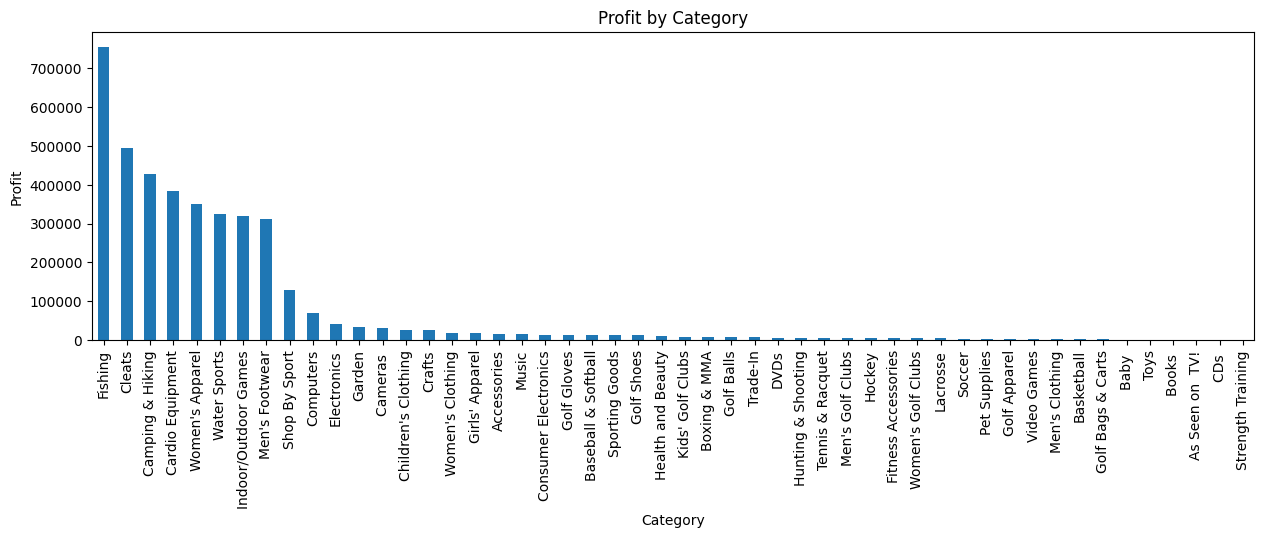

In [15]:
plt.figure(figsize=(15,4))
profit_category.plot(kind='bar')
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()

Some categories generate strong sales but relatively lower profit margins, indicating pricing or operational cost issues.

Shipping cost Vs Profit

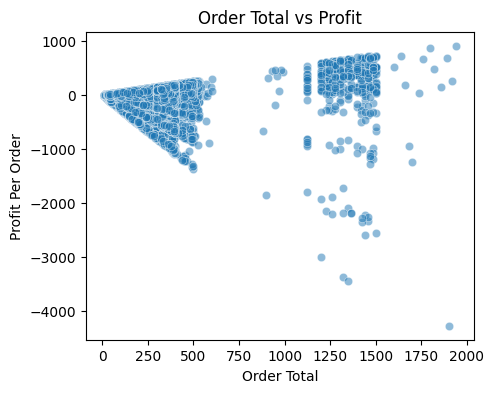

In [16]:
plt.figure(figsize=(5,4))

sns.scatterplot(x='Order Item Total',y='Order Profit Per Order',data=df,alpha=0.5)

plt.title("Order Total vs Profit")
plt.xlabel("Order Total")
plt.ylabel("Profit Per Order")

plt.show()

Higher order values generally contribute to increased profitability, although some high-value orders still generate low profit margins, indicating possible discounting or operational inefficiencies.

Monthly Sales Trend

In [17]:
monthly_sales=(df.groupby('Order Month')['Sales'].sum())
monthly_sales

Order Month
1     3.285387e+06
2     2.895042e+06
3     3.118581e+06
4     2.993697e+06
5     3.115664e+06
6     3.018855e+06
7     3.111459e+06
8     3.086627e+06
9     3.050190e+06
10    3.349347e+06
11    2.840779e+06
12    2.911107e+06
Name: Sales, dtype: float64

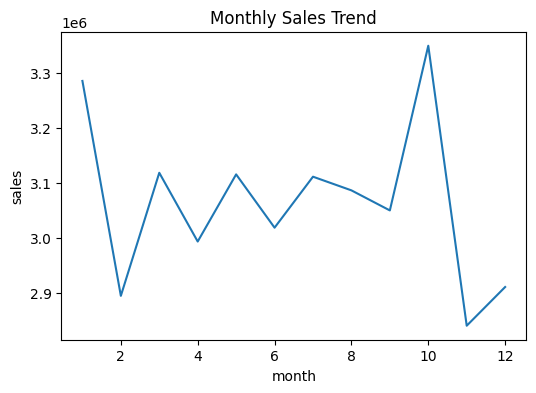

In [18]:
plt.figure(figsize=(6,4))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("month")
plt.ylabel("sales")
plt.show()

Sales fluctuate seasonally across months, indicating peak purchasing periods and demand cycles.

Delay Prediction Analysis

In [20]:
delay_percentage=(df['Delayed'].mean())*100
print("Delay percentage : ",delay_percentage)

Delay percentage :  54.83132870542219


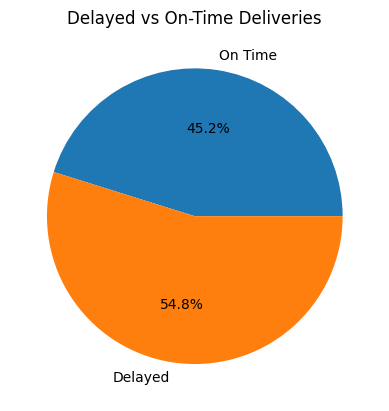

In [21]:
labels=['On Time','Delayed']
values=[100-delay_percentage,delay_percentage]
plt.pie(values,labels=labels,autopct='%1.1f%%')

plt.title("Delayed vs On-Time Deliveries")
plt.show()

The delay ratio highlights significant operational risks impacting customer satisfaction and delivery efficiency.

Top Profitable Regions

In [22]:
region_profit=(df.groupby('Order Region')['Order Profit Per Order'].sum().sort_values(ascending=False))
region_profit

Order Region
Western Europe     625446.080548
Central America    616341.570651
South America      335154.400817
Northern Europe    233450.600647
Southern Europe    230829.229883
Southeast Asia     211551.489784
Oceania            200787.940492
Caribbean          171825.640024
South Asia         165534.950127
West of USA        164940.660455
East of USA        156263.300194
Eastern Asia       147279.770639
US Center          131094.229875
West Asia          118815.410047
South of  USA       88114.879898
West Africa         80030.270031
Eastern Europe      79717.049920
North Africa        64599.860009
East Africa         43167.729927
Central Africa      33447.269960
Southern Africa     30826.050146
Canada              23900.709960
Central Asia        13045.280051
Name: Order Profit Per Order, dtype: float64

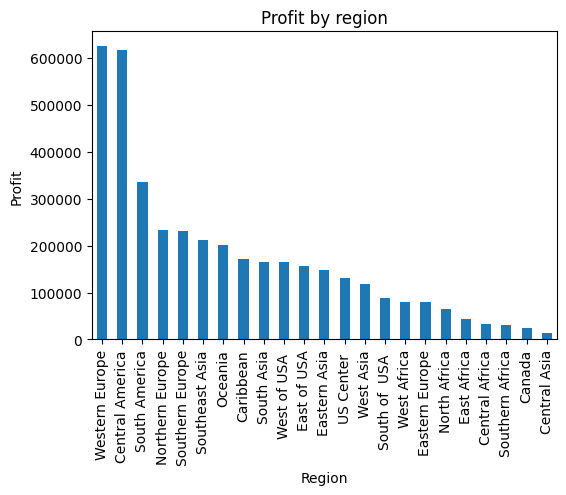

In [26]:
plt.figure(figsize=(6,4))
region_profit.plot(kind='bar')
plt.title("Profit by region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()

Some regions contribute significantly higher profits, making them strategically important markets for business expansion.

Correlation Heatmap

In [28]:
numeric_df=df.select_dtypes(include=np.number)

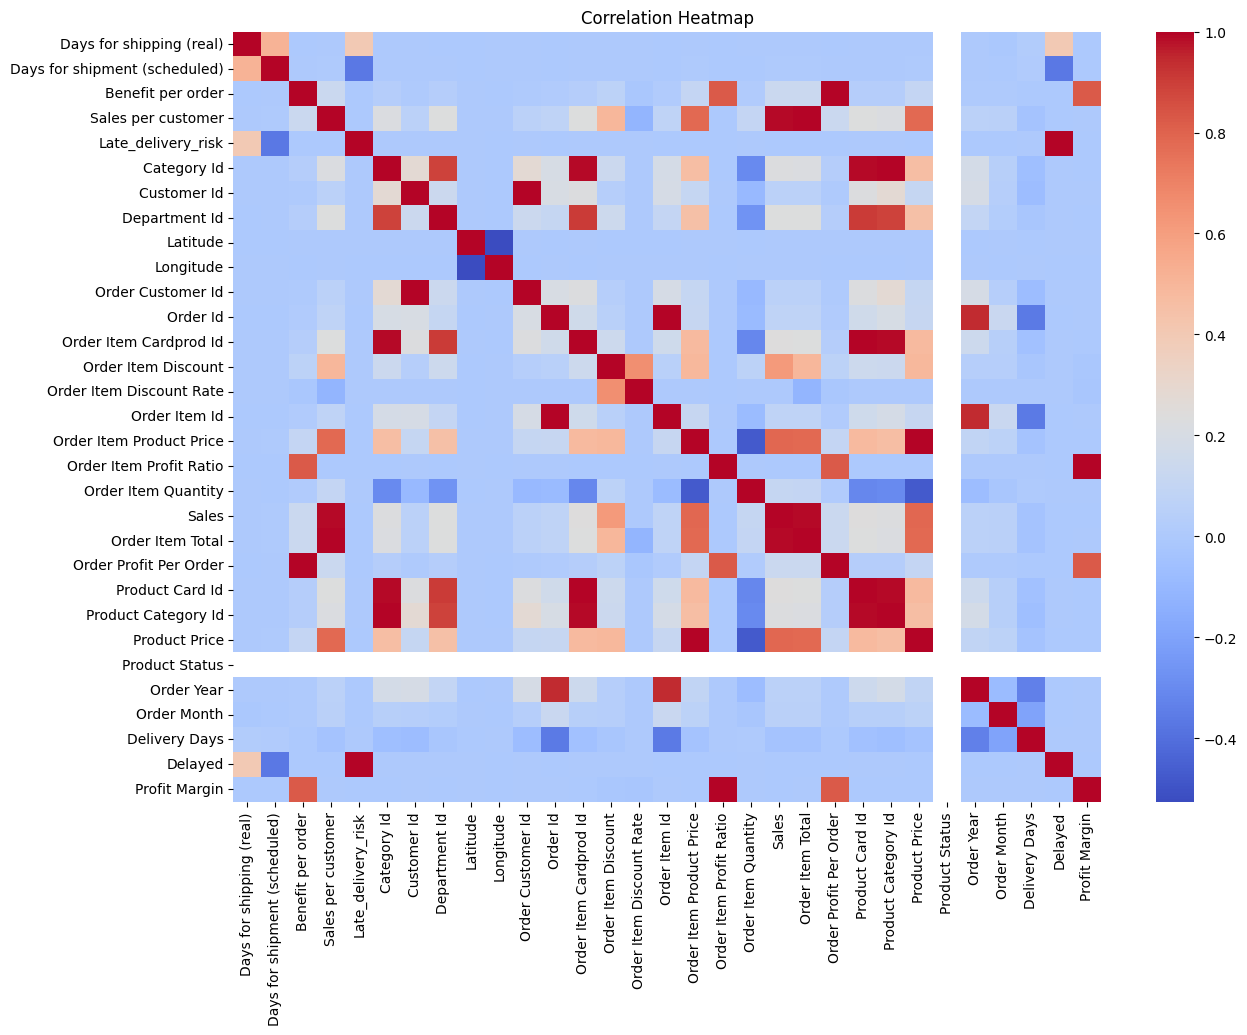

In [29]:
plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(),cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()